In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from skimage.feature import graycomatrix, graycoprops

import cv2
import matplotlib.image as mpimg

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


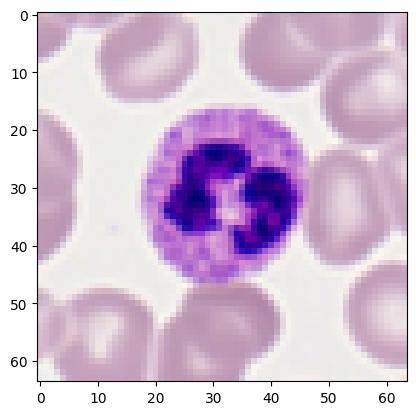

In [6]:
img = mpimg.imread('/content/drive/MyDrive/Blood_Cancer/Sample_1110.tiff')

plt.imshow(img)

BATCH_SIZE = 32
EPOCHS = 20
IMG_SIZE = 224

In [7]:
def compute_glcm_features(image_gray_np):
    glcm = graycomatrix(image_gray_np, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    return contrast, energy, homogeneity, correlation

Median Filtering Time: 0.0116 seconds
Otsu Thresholding Time: 0.0187 seconds


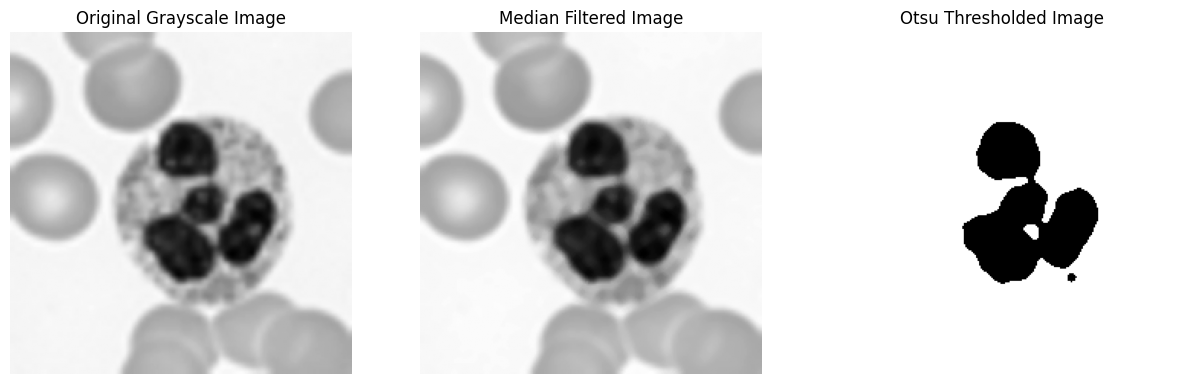

GLCM Features After Median Filter:
Contrast: 19.558215887251762
Energy: 0.18306704541424912
Homogeneity: 0.6094058349887087
Correlation: 0.9962246595232623
Image 1/100: Preproc=0.3730s | Median=0.0002s | GLCM=0.0029s | Otsu=0.0003s | Total=0.3765s
Image 2/100: Preproc=0.4641s | Median=0.0003s | GLCM=0.0034s | Otsu=0.0005s | Total=0.4682s
Image 3/100: Preproc=0.2954s | Median=0.0002s | GLCM=0.0032s | Otsu=0.0004s | Total=0.2992s
Image 4/100: Preproc=0.3072s | Median=0.0003s | GLCM=0.0035s | Otsu=0.0004s | Total=0.3115s
Image 5/100: Preproc=0.3095s | Median=0.0003s | GLCM=0.0036s | Otsu=0.0007s | Total=0.3140s
Image 6/100: Preproc=0.3280s | Median=0.0002s | GLCM=0.0035s | Otsu=0.0004s | Total=0.3321s
Image 7/100: Preproc=0.3534s | Median=0.0004s | GLCM=0.0035s | Otsu=0.0004s | Total=0.3576s
Image 8/100: Preproc=0.3254s | Median=0.0003s | GLCM=0.0031s | Otsu=0.0004s | Total=0.3292s
Image 9/100: Preproc=0.3239s | Median=0.0002s | GLCM=0.0034s | Otsu=0.0004s | Total=0.3279s
Image 10/100: Pr

In [8]:
import time
def preprocess_image(image_path):
    image = Image.open(image_path)

    if image.mode == 'RGBA':
        image = image.convert('RGB')

    # Resize the image to 224x224
    image = image.resize((IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    image_gray = image.convert('L')
    image_gray_np = np.array(image_gray)

    return image_gray_np

def apply_median_filter(image_gray_np):
    # Apply median filter
    median_filtered_image = cv2.medianBlur(image_gray_np, ksize=5)

    return median_filtered_image

def compute_glcm_after_filter(median_filtered_image):
    # Compute GLCM features
    glcm = graycomatrix(median_filtered_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    return contrast, energy, homogeneity, correlation

def apply_otsu_threshold(image_gray_np):
    _, binary_image = cv2.threshold(image_gray_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    binary_image_rgb = np.stack((binary_image,) * 3, axis=-1)
    binary_image_rgb = binary_image_rgb / 255.0

    return binary_image_rgb

def display_images(original, filtered, thresholded):
    plt.figure(figsize=(15, 5))

    # Original grayscale image
    plt.subplot(1, 3, 1)
    plt.title('Original Grayscale Image')
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    # Median filtered image
    plt.subplot(1, 3, 2)
    plt.title('Median Filtered Image')
    plt.imshow(filtered, cmap='gray')
    plt.axis('off')

    # Otsu thresholded image
    plt.subplot(1, 3, 3)
    plt.title('Otsu Thresholded Image')
    plt.imshow(thresholded, cmap='gray')
    plt.axis('off')

    plt.show()

IMAGE_PATH = '/content/drive/MyDrive/Blood_Cancer/Sample_1240.tiff'

# Step 1: Preprocess the image
image_gray_np = preprocess_image(IMAGE_PATH)

# Step 2: Apply Median Filter
start = time.time()
median_filtered_image = apply_median_filter(image_gray_np)
end = time.time()
print(f"Median Filtering Time: {end - start:.4f} seconds")

# Step 3: Compute GLCM after Median Filter
contrast, energy, homogeneity, correlation = compute_glcm_after_filter(median_filtered_image)

start = time.time()
binary_image_rgb = apply_otsu_threshold(median_filtered_image)
end = time.time()
print(f"Otsu Thresholding Time: {end - start:.4f} seconds")

# Display the images
display_images(image_gray_np, median_filtered_image, binary_image_rgb)

print(f"GLCM Features After Median Filter:")
print(f"Contrast: {contrast}")
print(f"Energy: {energy}")
print(f"Homogeneity: {homogeneity}")
print(f"Correlation: {correlation}")

def load_and_preprocess_dataset(BASE_PATH, NUM_IMAGES):
    all_image_paths = [BASE_PATH.format(i) for i in range(1, NUM_IMAGES + 1)]
    processed_images = []
    glcm_features = []

    preprocessing_times, median_times, glcm_times, otsu_times, total_times = [], [], [], [], []

    total_start = time.time()

    for idx, path in enumerate(all_image_paths, start=1):
        image_start = time.time()

        # --- Preprocessing (grayscale only) ---
        start = time.time()
        image_gray_np = preprocess_image(path)   # return only grayscale
        preprocessing_time = time.time() - start

        # --- Median Filter ---
        start = time.time()
        median_filtered_image = apply_median_filter(image_gray_np)
        median_time = time.time() - start

        # --- GLCM ---
        start = time.time()
        contrast, energy, homogeneity, correlation = compute_glcm_features(image_gray_np)
        glcm_time = time.time() - start

        # --- Otsu Thresholding ---
        start = time.time()
        binary_image_rgb = apply_otsu_threshold(median_filtered_image)
        otsu_time = time.time() - start

        processed_images.append(binary_image_rgb)
        glcm_features.append([contrast, energy, homogeneity, correlation])

        total_image_time = time.time() - image_start

        preprocessing_times.append(preprocessing_time)
        median_times.append(median_time)
        glcm_times.append(glcm_time)
        otsu_times.append(otsu_time)
        total_times.append(total_image_time)

        print(f"Image {idx}/{NUM_IMAGES}: "
              f"Preproc={preprocessing_time:.4f}s | "
              f"Median={median_time:.4f}s | "
              f"GLCM={glcm_time:.4f}s | "
              f"Otsu={otsu_time:.4f}s | "
              f"Total={total_image_time:.4f}s")

        if idx % 100 == 0:
            elapsed = time.time() - total_start
            print(f"Processed {idx} images so far in {elapsed:.2f} seconds")

    total_end = time.time()
    dataset_total_time = total_end - total_start

    print(f"\n✅ Total Dataset Preprocessing Time ({NUM_IMAGES} images): {dataset_total_time:.2f} seconds")
    print(f"✅ Average Time per Image: {dataset_total_time / NUM_IMAGES:.4f} seconds")

    # --- Compute Averages ---
    print("\n🔎 Average Step-wise Timings:")
    print(f"Preprocessing Avg: {sum(preprocessing_times)/len(preprocessing_times):.4f}s")
    print(f"Median Filter Avg: {sum(median_times)/len(median_times):.4f}s")
    print(f"GLCM Computation Avg: {sum(glcm_times)/len(glcm_times):.4f}s")
    print(f"Otsu Thresholding Avg: {sum(otsu_times)/len(otsu_times):.4f}s")
    print(f"Total per Image Avg: {sum(total_times)/len(total_times):.4f}s")

    return np.array(processed_images), np.array(glcm_features)


NUM_IMAGES = 100
BASE_PATH = '/content/drive/MyDrive/Blood_Cancer/Sample_{}.tiff'

images, glcm_features = load_and_preprocess_dataset(BASE_PATH, NUM_IMAGES)
labels = [1] * NUM_IMAGES

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print("Training data shape:", x_train.shape)
print("Validation data shape:", x_test.shape)

# Calculate average GLCM features
mean_glcm = np.mean(glcm_features, axis=0)

contrast_avg = mean_glcm[0]
correlation_avg = mean_glcm[1]
energy_avg = mean_glcm[2]
homogeneity_avg = mean_glcm[3]

print(f"Average Contrast: {contrast_avg}")
print(f"Average Correlation: {correlation_avg}")
print(f"Average Energy: {energy_avg}")
print(f"Average Homogeneity: {homogeneity_avg}")

In [9]:
mean_glcm = np.mean(glcm_features, axis=0)

contrast_avg = mean_glcm[0]
correlation_avg = mean_glcm[1]
energy_avg = mean_glcm[2]
homogeneity_avg = mean_glcm[3]


print(f"Average Contrast: {contrast_avg}")
print(f"Average Correlation: {correlation_avg}")
print(f"Average Energy: {energy_avg}")
print(f"Average Homogeneity: {homogeneity_avg}")

Average Contrast: 16.709399623638696
Average Correlation: 0.1675253746751409
Average Energy: 0.5655732783936149
Average Homogeneity: 0.9966856054270039


In [10]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()


In [11]:
def build_resnet_model(input_shape):
    base_model = tf.keras.applications.ResNet50(
        input_shape=input_shape,
        include_top=False,  # add custom layers on top
        weights=None
    )

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),  # Pooling
        layers.Dense(1024, activation='relu'),  # Fully connected layer
        layers.Dropout(0.5),  # Regularization
        layers.Dense(1, activation='sigmoid')  # Single neuron for binary classification
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Build the model
model = build_resnet_model((IMG_SIZE, IMG_SIZE, 3))


In [12]:
train_generator = train_datagen.flow(x_train,y_train, batch_size=BATCH_SIZE, shuffle=True)
val_generator = val_datagen.flow(x_test,y_test, batch_size=BATCH_SIZE, shuffle=False)
import time

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    validation_steps=len(x_test) // BATCH_SIZE,
    epochs=EPOCHS
)

end_time = time.time()

# Calculate total training time
total_training_time = end_time - start_time
print(f"Total Training Time: {total_training_time:.2f} seconds")

# Calculate average time per epoch
average_time_per_epoch = total_training_time / EPOCHS
print(f"Average Time per Epoch: {average_time_per_epoch:.2f} seconds")

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 70s 6s/step - accuracy: 0.7500 - loss: 0.4453 - val_accuracy: 1.0000 - val_loss: 3.4165e-04
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 1.0000 - loss: 4.6776e-16 - val_accuracy: 1.0000 - val_loss: 1.3764e-07
Epoch 3/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 1.0000 - loss: 8.2994e-19 - val_accuracy: 1.0000 - val_loss: 3.4199e-07
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 2.2153e-24 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 5/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step - accuracy: 1.0000 - loss: 5.1207e-26 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 2.0983e-32 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step - accuracy: 1.0000 - loss: 6.1205e-30 - val_accuracy: 1.0000 - val_loss: 7.0010e-04
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 6.9431e-36 - val_accuracy: 1.0000 - val_loss: 2.7150e-04
Epoch 9/20


...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 1.0000 - loss: 6.2081e-35 - val_accuracy: 1.0000 - val_loss: 2.4057e-08
Epoch 16/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 1.0000 - loss: 6.3939e-37 - val_accuracy: 1.0000 - val_loss: 1.0938e-08
Epoch 17/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step - accuracy: 1.0000 - loss: 2.4169e-36 - val_accuracy: 1.0000 - val_loss: 2.3787e-09
Epoch 18/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 1.8831e-34 - val_accuracy: 1.0000 - val_loss: 1.1433e-09
Epoch 19/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 1.0000 - loss: 2.6572e-38 - val_accuracy: 1.0000 - val_loss: 2.4163e-10
Epoch 20/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 1.0000 - loss: 1.6969e-36 - val_accuracy: 1.0000 - val_loss: 1.1596e-10
Total Training Time: 110.90 seconds
Average Time per Epoch: 5.55 seconds


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [13]:
val_loss, val_acc = model.evaluate(val_generator)
print(f'Validation Accuracy: {val_acc*100:.2f}%')




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 1.0000 - loss: 1.1596e-10
Validation Accuracy: 100.00%


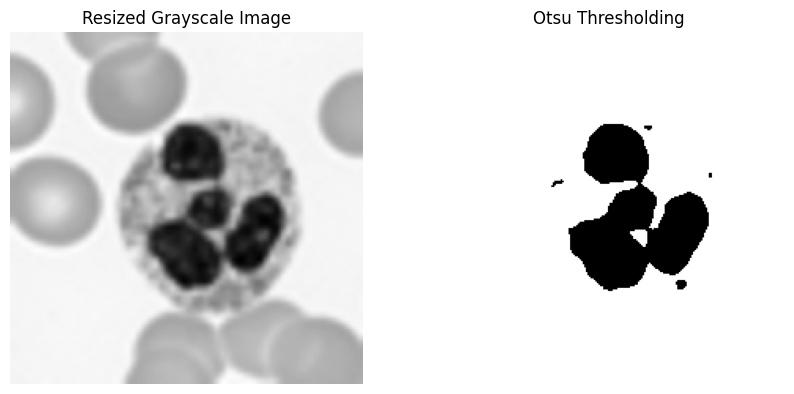

Optimal Threshold Value: 140.0


In [14]:
# Image parameters
IMG_SIZE = 224  # Resize images to this size
IMAGE_PATH = '/content/drive/MyDrive/Blood_Cancer/Sample_1240.tiff'  # Path for a single image

# Function to load, resize, and preprocess image (including Otsu thresholding)
def load_and_preprocess_image(image_path):
    # Load the image using PIL
    img = Image.open(image_path)

    # Convert RGBA to RGB if necessary
    if img.mode == 'RGBA':
        img = img.convert('RGB')

    # Resize image to 224x224
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert the resized image to grayscale for Otsu thresholding
    img_gray = img.convert('L')  # Convert to grayscale

    # Convert grayscale image to a NumPy array for OpenCV operations
    img_gray_np = np.array(img_gray)

    # Apply Otsu's thresholding
    thresh_value, binary_image = cv2.threshold(img_gray_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Display original grayscale and Otsu-thresholded images side by side
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title('Resized Grayscale Image')
    plt.imshow(img_gray_np, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Otsu Thresholding')
    plt.imshow(binary_image, cmap='gray')
    plt.axis('off')

    plt.show()

    print(f'Optimal Threshold Value: {thresh_value}')

    return binary_image

# Test the function with the specified image
processed_image = load_and_preprocess_image(IMAGE_PATH)


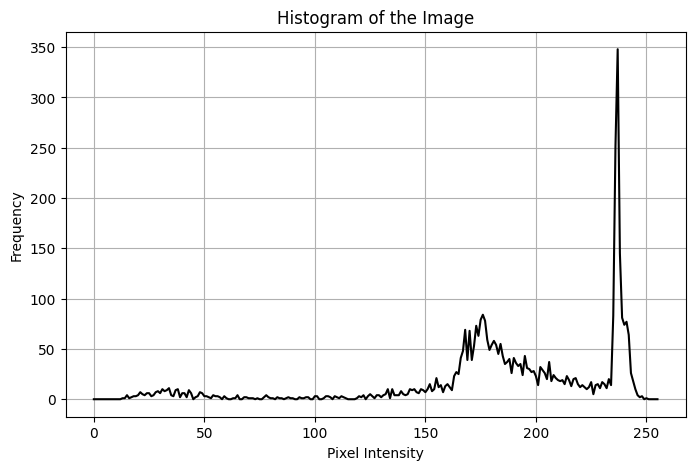

In [15]:
import cv2
import matplotlib.pyplot as plt

# Load the grayscale image
image_path = '/content/drive/MyDrive/Blood_Cancer/Sample_1110.tiff'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Compute the histogram
histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

# Plot the histogram
plt.figure(figsize=(8, 5))
plt.plot(histogram, color='black')
plt.title("Histogram of the Image")
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



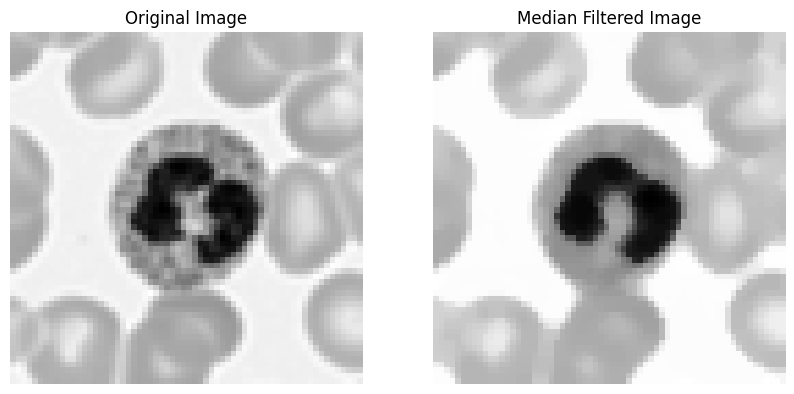

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def load_and_preprocess_image(image_path):
    # Load the image using PIL
    img = Image.open(image_path)

    # Convert RGBA to RGB if necessary
    if img.mode == 'RGBA':
        img = img.convert('RGB')

    # Resize image to 224x224
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert the resized image to grayscale for Otsu thresholding
    img_gray = img.convert('L')  # Convert to grayscale

    # Convert grayscale image to a NumPy array for OpenCV operations
    img_gray_np = np.array(img_gray)

    # Apply Otsu's thresholding
    median_filtered_image = cv2.medianBlur(image, ksize=5)  # ksize is the size of the kernel (odd number)

    # Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Median Filtered Image')
    plt.imshow(median_filtered_image, cmap='gray')
    plt.axis('off')

    plt.show()

    return median_filtered_image

# Test the function with the specified image
processed_image = load_and_preprocess_image(IMAGE_PATH)

In [17]:
from skimage.feature import graycomatrix, graycoprops # Changed 'greycomatrix' to 'graycomatrix' and 'greycoprops' to 'graycoprops'

# Compute GLCM on the median filtered grayscale image
glcm = graycomatrix(median_filtered_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True) # Changed 'greycomatrix' to 'graycomatrix'

# Extract texture properties from the GLCM
contrast = graycoprops(glcm, 'contrast')[0, 0] # Changed 'greycoprops' to 'graycoprops'
energy = graycoprops(glcm, 'energy')[0, 0] # Changed 'greycoprops' to 'graycoprops'
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0] # Changed 'greycoprops' to 'graycoprops'
correlation = graycoprops(glcm, 'correlation')[0, 0] # Changed 'greycoprops' to 'graycoprops'

print(f"GLCM Features - Contrast: {contrast}, Energy: {energy}, Homogeneity: {homogeneity}, Correlation: {correlation}")

GLCM Features - Contrast: 19.558215887251762, Energy: 0.18306704541424912, Homogeneity: 0.6094058349887087, Correlation: 0.9962246595232623


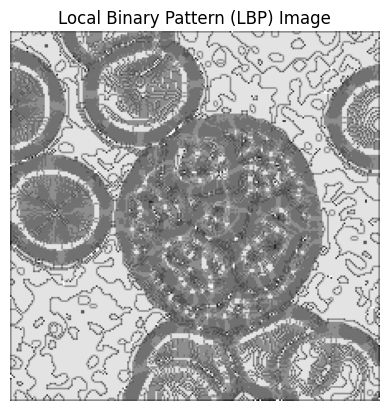

In [18]:
from skimage.feature import local_binary_pattern
radius = 1
n_points = 8 * radius
lbp_image = local_binary_pattern(median_filtered_image, n_points, radius, method='uniform')

# Visualize LBP image
plt.imshow(lbp_image, cmap='gray')
plt.title("Local Binary Pattern (LBP) Image")
plt.axis('off')
plt.show()

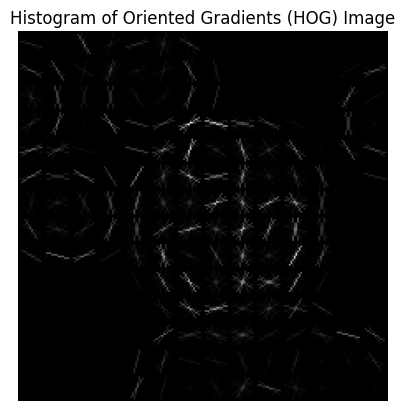

In [19]:
from skimage.feature import hog

# Compute HOG features
hog_features, hog_image = hog(median_filtered_image, orientations=8, pixels_per_cell=(16, 16),
                              cells_per_block=(1, 1), visualize=True)

# Visualize the HOG image
plt.imshow(hog_image, cmap='gray')
plt.title("Histogram of Oriented Gradients (HOG) Image")
plt.axis('off')
plt.show()


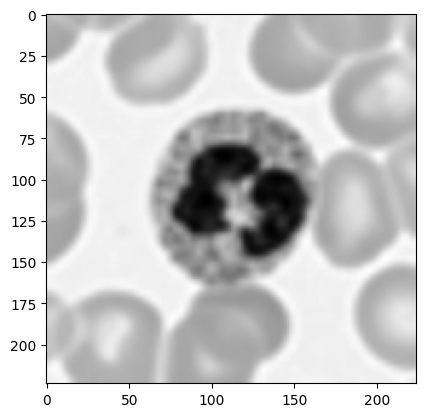

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the image
img_path = '/content/drive/MyDrive/Blood_Cancer/Sample_1110.tiff'
img = Image.open(img_path)

# Resize the image to 224x224
img_resized = img.resize((224, 224))

# Convert the resized image to grayscale
img_gray = img_resized.convert('L')

# Display the grayscale image
plt.imshow(img_gray, cmap='gray')
plt.show()



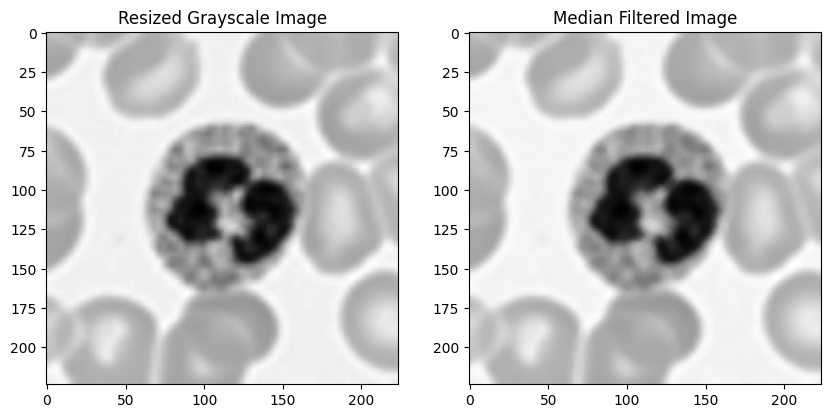

In [21]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define image size for resizing
IMG_SIZE = 224

# Step 1: Load, resize, and convert the image to grayscale
def preprocess_image(image_path):
    # Load image
    image = Image.open(image_path)

    # Convert to RGB if it's RGBA
    if image.mode == 'RGBA':
        image = image.convert('RGB')

    # Resize the image to the defined size
    image = image.resize((IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    image_gray = image.convert('L')
    image_gray_np = np.array(image_gray)

    return image_gray_np

# Step 2: Apply the median filter to the grayscale image
def apply_median_filter(image_gray_np):
    # Apply a median filter with a kernel size of 5
    median_filtered_image = cv2.medianBlur(image_gray_np, ksize=5)
    return median_filtered_image

# Example usage
IMAGE_PATH = '/content/drive/MyDrive/Blood_Cancer/Sample_1110.tiff'

# Preprocess and apply median filter
image_gray_np = preprocess_image(IMAGE_PATH)
median_filtered_image = apply_median_filter(image_gray_np)

# Display the original and filtered images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Resized Grayscale Image")
plt.imshow(image_gray_np, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Median Filtered Image")
plt.imshow(median_filtered_image, cmap='gray')

plt.show()

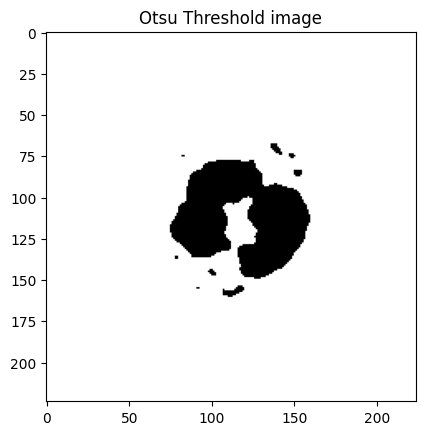

In [22]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load and resize the image
img_path = '/content/drive/MyDrive/Blood_Cancer/Sample_1110.tiff'
img = Image.open(img_path)
img_resized = img.resize((224, 224))

# Convert the resized image to grayscale
img_gray = img_resized.convert('L')
img_gray_np = np.array(img_gray)  # Convert to NumPy array for OpenCV

# Apply Otsu's thresholding
_, otsu_thresh_img = cv2.threshold(img_gray_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.title('Otsu Threshold image')
# Display the thresholded image
plt.imshow(otsu_thresh_img, cmap='gray')
plt.show()
